In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
df = pd.read_parquet("eda_banking.parquet")
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Fraud,RiskScore,BalancePerProduct,AgeRisk,HighValueCustomer,LowCreditRisk,MarketingScore,ComplainFlag,LowSatisfaction,OperationalRiskScore
0,619,France,Female,42,2,11983969.0,1,1,1,10134888.0,1,1,2,DIAMOND,464,0,1,0.000000,0,0,0,0,1,1,2
1,608,Spain,Female,41,1,8380786.0,1,0,1,11254258.0,0,1,3,DIAMOND,456,0,1,41903.930000,0,0,0,1,1,0,1
2,502,France,Female,42,8,15966080.0,3,1,0,11393157.0,1,1,3,DIAMOND,377,0,3,39915.200000,0,1,0,1,1,0,2
3,699,France,Female,39,1,11983969.0,2,0,0,9382663.0,0,0,5,GOLD,350,0,1,0.000000,0,0,0,0,0,0,1
4,850,Spain,Female,43,2,12551082.0,1,1,1,7908410.0,0,0,5,GOLD,425,0,1,62755.410000,0,1,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,11983969.0,2,1,0,9627064.0,0,0,1,DIAMOND,300,0,1,0.000000,0,0,0,0,0,1,2
9996,516,France,Male,35,10,5736961.0,1,1,1,10169977.0,0,0,5,PLATINUM,771,0,0,28684.805000,0,0,0,0,0,0,0
9997,709,France,Female,36,7,11983969.0,1,0,1,4208558.0,1,1,3,SILVER,564,0,1,0.000000,0,0,0,0,1,0,1
9998,772,Germany,Male,42,3,7507531.0,2,1,0,9288852.0,1,1,2,GOLD,339,1,2,25025.103333,0,0,0,1,1,1,3


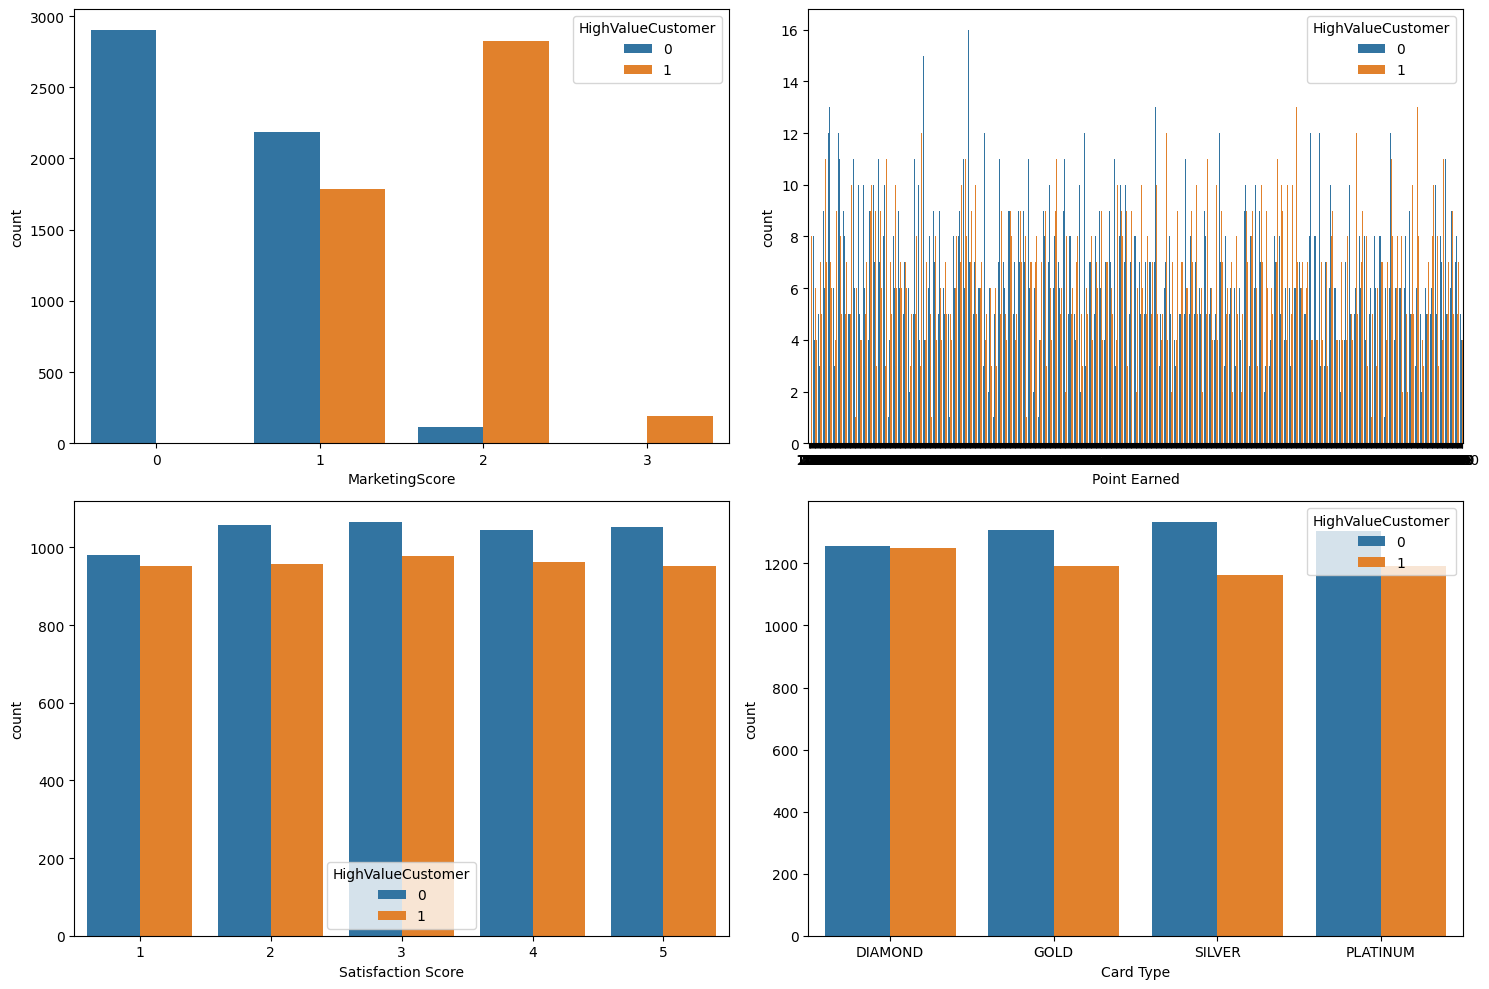

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Relationship of HighValueCustomer to identify problem based on "MarketingScore", "Point Earned", "Satisfaction Score", "Card Type"
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(x='MarketingScore', hue='HighValueCustomer', data=df, ax=axes[0, 0])
sns.countplot(x='Point Earned', hue='HighValueCustomer', data=df, ax=axes[0, 1])
sns.countplot(x='Satisfaction Score', hue='HighValueCustomer', data=df, ax=axes[1, 0])
sns.countplot(x='Card Type', hue='HighValueCustomer', data=df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

In [17]:
df['Point Earned'].describe()

count    10000.000000
mean       606.515100
std        225.924839
min        119.000000
25%        410.000000
50%        605.000000
75%        801.000000
max       1000.000000
Name: Point Earned, dtype: float64

In [4]:
df['HighValueCustomer'].value_counts()

0    5201
1    4799
Name: HighValueCustomer, dtype: int64

In [3]:
df['LowCreditRisk'].value_counts()

0    9368
1     632
Name: LowCreditRisk, dtype: int64

In [53]:
df['Balance'].describe()

count    1.000000e+04
mean     1.198319e+07
std      2.404337e+06
min      3.768690e+05
25%      1.115811e+07
50%      1.198397e+07
75%      1.276442e+07
max      2.508981e+07
Name: Balance, dtype: float64

In [54]:
df[df['Balance'] > 15000000].sample(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Fraud,RiskScore,BalancePerProduct,AgeRisk,HighValueCustomer,LowCreditRisk,MarketingScore,ComplainFlag,LowSatisfaction,OperationalRiskScore
2643,632,France,Male,27,4,19312585.0,1,1,1,15266585.0,0,0,4,GOLD,262,0,1,96562.925000,0,1,0,1,0,0,0
6441,514,France,Male,45,1,17882779.0,1,1,0,6037518.0,0,0,5,DIAMOND,493,0,2,89413.895000,0,1,0,1,0,0,1
9763,619,France,Male,27,1,15448398.0,1,1,0,15639474.0,0,0,2,SILVER,431,0,2,77241.990000,0,1,0,1,0,1,2
8542,688,Germany,Female,40,8,15067971.0,2,0,1,19622638.0,0,0,4,GOLD,645,0,1,50226.570000,0,1,0,2,0,0,0
3076,678,Germany,Female,43,2,15339318.0,2,1,1,19382827.0,0,0,1,GOLD,274,0,1,51131.060000,0,1,0,2,0,1,1
5958,540,France,Female,40,3,16529812.0,1,0,1,19986275.0,0,0,4,GOLD,656,0,1,82649.060000,0,1,0,1,0,0,0
1338,625,France,Male,52,5,16497801.0,1,1,1,6778849.0,0,0,3,PLATINUM,482,0,1,82489.005000,0,1,0,1,0,0,0
5687,505,Germany,Female,37,6,15986390.0,2,0,1,12530787.0,0,0,1,GOLD,421,0,1,53287.966667,0,1,0,2,0,1,1
8733,749,Spain,Male,42,9,22226763.0,1,0,0,10110885.0,1,1,4,GOLD,763,0,3,111133.815000,0,1,0,2,1,0,2
6717,663,Spain,Female,58,5,21610988.0,1,0,1,7417671.0,1,1,2,SILVER,251,1,2,108054.940000,0,1,0,2,1,1,2


In [55]:
# make BalancePerProduct into 2 decimal behind the comma
df['BalancePerProduct'] = df['BalancePerProduct'].round(3)
pd.DataFrame(df['BalancePerProduct'])

,BalancePerProduct
0,0.000
1,41903.930
2,39915.200
3,0.000
4,62755.410
...,...
9995,0.000
9996,28684.805
9997,0.000
9998,25025.103
